<a id="top"></a>
# Chapter 2 — Linear ion drift and window functions

**MemrisTec Compact Models — Memristor Physics from Paper to Code** · chapter 2 of 6

[◀ 1 The memristor as a state-controlled resistor](Memristec_01_State_Controlled_Resistor.ipynb) · [Contents of the book](README.md) · [3 Threshold switching: VTEAM ▶](Memristec_03_Threshold_Switching_VTEAM.ipynb)

**In this chapter**

- [§5 The terminal-state problem](#sec-5)
- [§6 Three window functions](#sec-6)
- [§7 The loops with the three windows](#sec-7)
- [§8 Stuck at the wall: Joglekar versus Biolek](#sec-8)

All chapters: [0](Memristec_00_Introduction.ipynb) · [1](Memristec_01_State_Controlled_Resistor.ipynb) · [2](Memristec_02_Linear_Ion_Drift_and_Windows.ipynb) · [3](Memristec_03_Threshold_Switching_VTEAM.ipynb) · [4](Memristec_04_Filamentary_Switching.ipynb) · [5](Memristec_05_Pulses_and_Neuromorphic_Use.ipynb) · [6](Memristec_06_Benchmarking_and_the_Library.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–26), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in MEMRISTEC_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("MEMRISTEC_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "memristec_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import memristec_tools as mt
from memristec_tools import (LinearIonDrift, Yakopcic2013, VTEAM2015, StanfordPKU2016, MODELS,
                             simulate, iv_sweep, loop_metrics, dynamic_route_map,
                             pulse_train, pulse_response, sine, triangular, rectangular)

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 5}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("memristec-skill", mt.__version__, "| numpy", np.__version__, "| chapter 2")
t_chapter_start = time.time()

memristec-skill 0.2.0 | numpy 2.5.2 | chapter 2


<a id="sec-5"></a>

## 5. The terminal-state problem

Chapter 1's model has no notion of the film's edges: $\dot x = k\,i$ keeps pushing the doped
front even when it has reached $w = D$ ($x = 1$) or $w = 0$. In the ODE nothing stops it; in
our driver the state is clipped to $[0, 1]$ after every step, which is a numerical fence, not
physics. A large drive shows the fence at work (2 V still stops at $x \approx 0.86$; 3 V
reaches the wall).

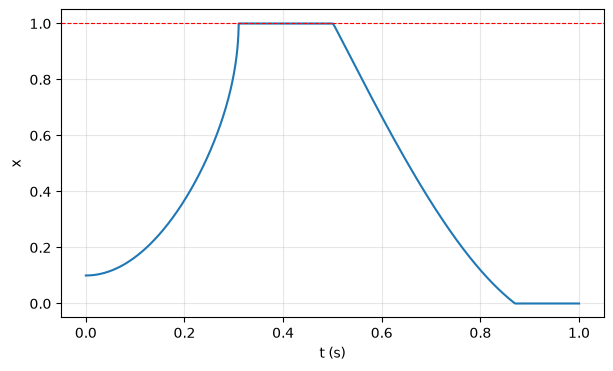

[PASS] the state hits the boundary x = 1
[PASS] and stays there for a finite time — 761 grid points at the wall


True

In [2]:
res = iv_sweep(LinearIonDrift(window="none"), 3.0, 1.0, cycles=1, n_per_cycle=4000)   # 3 V is enough to hit x = 1
fig, ax = plt.subplots()
ax.plot(res.t, res.x); ax.axhline(1.0, color="r", ls="--", lw=0.8); ax.set_xlabel("t (s)"); ax.set_ylabel("x")
show(fig)
caption("Linear ion drift without a window under a 3 V, 1 Hz sine: the state reaches the film "
        "boundary x = 1 and sits on the driver's clip for the rest of the positive half-cycle.")
check("the state hits the boundary x = 1", res.x.max() == 1.0)
check("and stays there for a finite time", np.sum(res.x == 1.0) > 100, f"{np.sum(res.x == 1.0)} grid points at the wall")

<a id="sec-6"></a>

## 6. Three window functions

A **window function** $f(x)$ multiplies the drift rate, $\dot x = k\,i\,f(x, i)$, and vanishes
at the boundaries so that the dopant front slows down before it hits the edge. Three
published choices, all with $p$ a positive integer:

| window | $f$ | source |
|---|---|---|
| Joglekar | $1 - (2x-1)^{2p}$ | Joglekar & Wolf 2009, eq. 12 |
| Biolek | $1 - (x - \mathrm{stp}(-i))^{2p}$, $\mathrm{stp}(u) = 1$ for $u \ge 0$ else $0$ | Biolek, Biolek & Biolková 2009, eq. 8 |
| Prodromakis | $j\,\big(1 - [(x-0.5)^2 + 0.75]^p\big)$ | Prodromakis et al. 2011, eq. 3 |

Joglekar's window is symmetric and vanishes at both ends whatever the current: a state that
has reached a boundary can never leave it (the **terminal-state problem** in its ODE form).
Biolek's window depends on the current's sign: it vanishes only at the boundary the current
is pushing towards, so reversing the current frees the state. Prodromakis's window is bounded
by $j$, never negative on $[0, 1]$, and $p$ tunes its flatness.

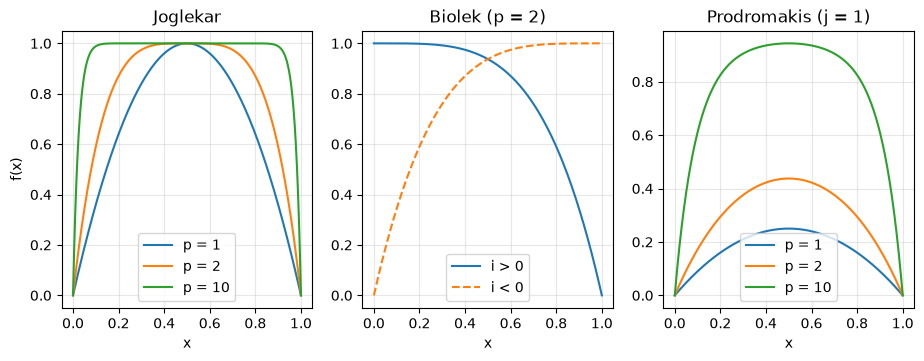

[PASS] Joglekar vanishes at both boundaries
[PASS] Biolek at x = 1: zero for i > 0, one for i < 0
[PASS] Prodromakis is bounded by j and non-negative on [0, 1]


True

In [3]:
xs = np.linspace(0.0, 1.0, 401)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for p in (1, 2, 10):
    axes[0].plot(xs, [LinearIonDrift(window="joglekar", p=p).window_value(x, 1e-3) for x in xs], label=f"p = {p}")
    axes[2].plot(xs, [LinearIonDrift(window="prodromakis", p=p).window_value(x, 1e-3) for x in xs], label=f"p = {p}")
b = LinearIonDrift(window="biolek", p=2)
axes[1].plot(xs, [b.window_value(x, +1e-3) for x in xs], label="i > 0")
axes[1].plot(xs, [b.window_value(x, -1e-3) for x in xs], "--", label="i < 0")
for ax, title in zip(axes, ("Joglekar", "Biolek (p = 2)", "Prodromakis (j = 1)")):
    ax.set_title(title); ax.set_xlabel("x"); ax.legend()
axes[0].set_ylabel("f(x)")
show(fig)
caption("The three window functions. Joglekar's vanishes at both ends for any current; "
        "Biolek's vanishes only at the end the current pushes towards; Prodromakis's is bounded "
        "by j and flattens as p grows.")

j = LinearIonDrift(window="joglekar", p=10)
check("Joglekar vanishes at both boundaries", abs(j.window_value(0.0, 1e-3)) < 1e-12 and abs(j.window_value(1.0, 1e-3)) < 1e-12)
check("Biolek at x = 1: zero for i > 0, one for i < 0", b.window_value(1.0, 1e-3) == 0.0 and b.window_value(1.0, -1e-3) == 1.0)
pr = LinearIonDrift(window="prodromakis", p=2, j=1.0)
vals = np.array([pr.window_value(x, 1e-3) for x in xs])
check("Prodromakis is bounded by j and non-negative on [0, 1]", vals.max() <= 1.0 and vals.min() >= 0.0 and abs(vals[200] - (1 - 0.75 ** 2)) < 1e-12)

<a id="sec-7"></a>

## 7. The loops with the three windows

With the parameters of the library's `HP_Biolek2009` folder read from its `model.yml`
($R_{\rm off} = 38\ \text{kΩ}$, initial resistance 28 kΩ, i.e. $x_0 \approx 0.26$) and a
1.2 V, 1 Hz sine, all three windows give a pinched loop. Away from the boundaries the Joglekar
and Biolek windows coincide (both are $1 - x^{2p}$-like corrections that are ~1 in the middle),
so their loops are indistinguishable here; the Prodromakis window with $p = 10$ is smaller in
the middle and gives a slightly smaller loop.

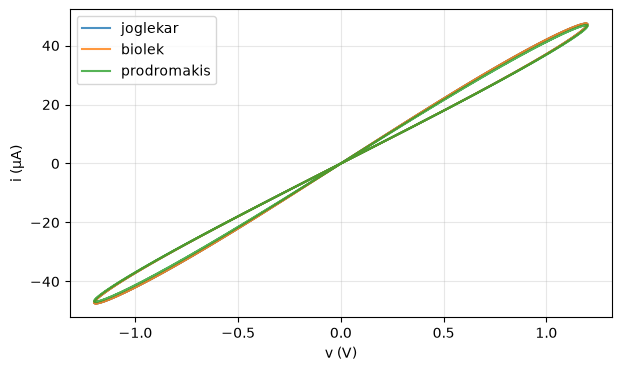

[PASS] all three loops are pinched
[PASS] Joglekar and Biolek areas agree within 1 % — 1.7198e-05 vs 1.7198e-05 V·A
[PASS] Prodromakis (p = 10) gives a smaller loop — 1.5190e-05 V·A
[PASS] the state stays well inside (0, 1) — x_max = 0.411


True

In [4]:
fig, ax = plt.subplots()
areas, xmax, pinched = {}, {}, {}
for w in ("joglekar", "biolek", "prodromakis"):
    r = iv_sweep(LinearIonDrift(window=w, R_off=38e3, x0=0.26), 1.2, 1.0, cycles=2, n_per_cycle=2000)
    met = loop_metrics(r)
    areas[w], xmax[w], pinched[w] = met["area"], r.x.max(), met["pinched_at_origin"]
    ax.plot(r.v, 1e6 * r.i, label=w, alpha=0.8)
ax.set_xlabel("v (V)"); ax.set_ylabel("i (µA)"); ax.legend()
show(fig)
caption("Pinched loops of the linear ion drift model with the Joglekar, Biolek and Prodromakis "
        "windows (p = 10, R_off = 38 kΩ, x0 = 0.26, 1.2 V at 1 Hz, two periods). Joglekar and "
        "Biolek coincide because the state never approaches a boundary.")
check("all three loops are pinched", all(pinched.values()))
check("Joglekar and Biolek areas agree within 1 %", abs(areas["joglekar"] - areas["biolek"]) < 0.01 * areas["joglekar"],
      f"{areas['joglekar']:.4e} vs {areas['biolek']:.4e} V·A")
check("Prodromakis (p = 10) gives a smaller loop", areas["prodromakis"] < areas["joglekar"], f"{areas['prodromakis']:.4e} V·A")
check("the state stays well inside (0, 1)", all(0.26 <= v <= 0.5 for v in xmax.values()), f"x_max = {max(xmax.values()):.3f}")

<a id="sec-8"></a>

## 8. Stuck at the wall: Joglekar versus Biolek

Push the state to the boundary with a long positive pulse, then reverse the voltage. With
Joglekar's window the state arrives at $x = 1$, where $f = 0$ for *any* current, and stays
there — the negative half does nothing. With Biolek's window the reversed current sees
$f(1, i<0) = 1$ and pulls the state straight back. This is the whole reason the Biolek window
exists, and the reason the folder named "Biolek" in the library, which actually implements
Joglekar's window (finding P-1 in the study repo), would show the wrong behaviour here.

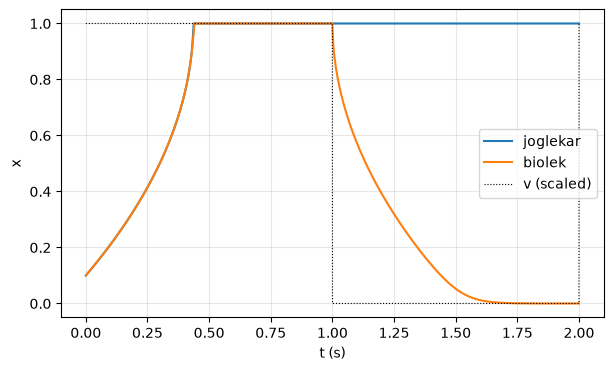

[PASS] Joglekar: at the wall after 1 s and still there at 2 s
[PASS] Biolek: near the wall after 1 s, back near 0 at 2 s — x(1 s) = 0.9938, x(2 s) = 4.63e-05


True

In [5]:
t = np.linspace(0.0, 2.0, 8001)
v = rectangular(t, 1.5, 0.5)              # +1.5 V for 1 s, then -1.5 V for 1 s
fig, ax = plt.subplots()
xs_end = {}
for w in ("joglekar", "biolek"):
    r = simulate(LinearIonDrift(window=w, p=10), t, v)
    xs_end[w] = (r.x[4000], r.x[-1])
    ax.plot(r.t, r.x, label=w)
ax.plot(t, 0.5 + v / 3, "k:", lw=0.8, label="v (scaled)")
ax.set_xlabel("t (s)"); ax.set_ylabel("x"); ax.legend()
show(fig)
caption("A +1.5 V pulse for one second drives both models to the boundary; the following "
        "−1.5 V second frees the state only with the Biolek window (dotted line: the drive).")
check("Joglekar: at the wall after 1 s and still there at 2 s", xs_end["joglekar"][0] == 1.0 and xs_end["joglekar"][1] == 1.0)
check("Biolek: near the wall after 1 s, back near 0 at 2 s", xs_end["biolek"][0] > 0.99 and xs_end["biolek"][1] < 0.01,
      f"x(1 s) = {xs_end['biolek'][0]:.4f}, x(2 s) = {xs_end['biolek'][1]:.2e}")

### Exercises for chapter 2

**2.1** Repeat §7 with $p = 2$ instead of 10 for the Joglekar window. Does the loop get larger
or smaller, and why?

**2.2** The Prodromakis parameter $j$ scales the whole window. Show that doubling $j$ doubles
the state's excursion for a drive that stays away from the boundaries.

In [6]:
# 2.1 — a smaller p makes the window fall off earlier, so the effective rate in the middle is
#       lower and the loop smaller.
a10 = loop_metrics(iv_sweep(LinearIonDrift(window="joglekar", p=10, R_off=38e3, x0=0.26), 1.2, 1.0, cycles=2, n_per_cycle=2000))["area"]
a2 = loop_metrics(iv_sweep(LinearIonDrift(window="joglekar", p=2, R_off=38e3, x0=0.26), 1.2, 1.0, cycles=2, n_per_cycle=2000))["area"]
check("2.1 p = 2 gives a smaller loop than p = 10", a2 < a10, f"{a2:.3e} < {a10:.3e} V·A")

# 2.2 — j multiplies f, hence dx/dt; to first order the excursion x - x0 is linear in the rate.
#       Measured ratio 2.18: slightly above 2 because a larger excursion lowers R(x), which raises
#       the current and feeds back on the rate — the linearity holds only for a vanishing excursion.
r1 = iv_sweep(LinearIonDrift(window="prodromakis", j=1.0, x0=0.3), 0.3, 1.0, cycles=1, n_per_cycle=4000)
r2 = iv_sweep(LinearIonDrift(window="prodromakis", j=2.0, x0=0.3), 0.3, 1.0, cycles=1, n_per_cycle=4000)
e1, e2 = r1.x.max() - 0.3, r2.x.max() - 0.3
check("2.2 doubling j roughly doubles the excursion (ratio in [1.8, 2.3])", 1.8 < e2 / e1 < 2.3, f"ratio {e2 / e1:.3f}")

[PASS] 2.1 p = 2 gives a smaller loop than p = 10 — 1.677e-05 < 1.720e-05 V·A


[PASS] 2.2 doubling j roughly doubles the excursion (ratio in [1.8, 2.3]) — ratio 2.182

True

In [7]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 2 — checks passed : {_CHECKS['pass']}")
print(f"chapter 2 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 2 — checks passed : 13
chapter 2 — checks failed : 0
wall time                 : 3 s
Every quantitative claim in this notebook was verified in this run.
